# 🔬 Análise dos Filtros Wavelet Aprendidos (UWaveGestureLibrary)

## Objetivo
Verificar se os filtros aprendidos pelo `LearnedWaveletDWT1D_QMF` atendem às propriedades
matemáticas de filtros wavelet válidos — **para cada um dos 3 canais de acelerômetro**.

## Propriedades Verificadas
1. **Admissibilidade** – média zero do filtro high-pass (função mãe wavelet)
2. **Normalização** – norma L2 unitária dos filtros
3. **QMF (Quadrature Mirror Filter)** – relação $g[n] = (-1)^n h[L{-}1{-}n]$
4. **Perfect Reconstruction** – condição de Nyquist: $|H(\omega)|^2 + |H(\omega+\pi)|^2 = 2$
5. **Resposta em frequência** – filtro low-pass é passa-baixa e high-pass é passa-alta
6. **Ortogonalidade / Localização** – produto de escala e concentração tempo-frequência
7. **Comparação com wavelets clássicas** – vis-à-vis db2, db4, coif1, sym4
8. **Vanishing moments** – análise numérica do número de momentos nulos
9. **Diversidade entre canais e níveis**

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import pywt
import warnings
import json, zipfile, io, h5py
warnings.filterwarnings('ignore')

import os
os.environ['CUDA_VISIBLE_DEVICES'] = '-1'

import tensorflow as tf
from tensorflow.keras.models import load_model

import sys
sys.path.append('.')
sys.path.append('../../models')
from LWT import LearnedWaveletDWT1D_QMF, LearnedWaveletPair1D_QMF
from dl_utils import PatchEmbedding, TransformerBlock, SinusoidalPositionalEncoding

from config.experiment_config import (
    UWAVE_CONFIG, DATA_DIR, RESULTS_DIR, MODELS_DIR, SEED,
    WAVELET_CONFIG, LEARNED_WAVELET_CONFIG,
)

plt.style.use('seaborn-v0_8-whitegrid')
FILTER_DIR = RESULTS_DIR / 'filter_analysis'
FILTER_DIR.mkdir(parents=True, exist_ok=True)

N_CHANNELS = UWAVE_CONFIG['n_features']
CHANNEL_NAMES = ['Accel-X', 'Accel-Y', 'Accel-Z']

print(f'TensorFlow: {tf.__version__}')
print(f'Dataset: {UWAVE_CONFIG["dataset_name"]} | canais: {N_CHANNELS} | seq_len: {UWAVE_CONFIG["sequence_length"]}')
print(f'LWT config: levels={LEARNED_WAVELET_CONFIG["levels"]}, kernel_size={LEARNED_WAVELET_CONFIG["kernel_size"]}')
print('✅ Imports realizados com sucesso!')

I0000 00:00:1780189250.202472 1536865 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


TensorFlow: 2.21.0
Dataset: UWaveGestureLibrary | canais: 3 | seq_len: 315
LWT config: levels=3, kernel_size=8
✅ Imports realizados com sucesso!


## 1. Localizar e Carregar o Melhor Modelo Learned Wavelet

In [2]:
# Encontrar o melhor modelo learned_wavelet nos resultados
runs = sorted([p for p in RESULTS_DIR.glob('????-??-??*') if (p/'queue_status.json').exists()], reverse=True)
assert runs, 'Nenhuma run encontrada.'

cands = []
for f in runs[0].rglob('metrics.json'):
    m = json.loads(f.read_text())
    if 'learned_wavelet' in m.get('mode', ''):
        f1 = float(m.get('test_f1_macro', 0) or 0)
        cands.append((f1, m.get('arch', ''), m.get('mode', ''), f.parent))

cands.sort(reverse=True)
print(f'Total de modelos learned_wavelet encontrados: {len(cands)}')
print(f'\nTop-5:')
for f1, arch, mode, d in cands[:5]:
    print(f'  F1={f1:.4f} | {arch:15s} | {mode:30s} | {d.relative_to(RESULTS_DIR)}')

best_f1, best_arch, best_mode, best_dir = cands[0]
print(f'\n✅ Melhor: {best_arch} ({best_mode}) — F1={best_f1:.4f}')
print(f'   Dir: {best_dir.relative_to(RESULTS_DIR)}')

# Carregar modelo com custom_objects (incluindo classes do Transformer)
custom_objects = {
    "LearnedWaveletDWT1D_QMF": LearnedWaveletDWT1D_QMF,
    "LearnedWaveletPair1D_QMF": LearnedWaveletPair1D_QMF,
    "PatchEmbedding": PatchEmbedding,
    "TransformerBlock": TransformerBlock,
    "SinusoidalPositionalEncoding": SinusoidalPositionalEncoding,
}
model = tf.keras.models.load_model(best_dir / 'model.keras', custom_objects=custom_objects, compile=False)
model.summary()

Total de modelos learned_wavelet encontrados: 1296

Top-5:
  F1=0.8688 |                 | learned_wavelet_no_warmup      | 2026-05-29_231129/Transformer_learned_wavelet_no_warmup/cfg109
  F1=0.8672 |                 | learned_wavelet                | 2026-05-29_231129/MLP_learned_wavelet/cfg038
  F1=0.8665 |                 | learned_wavelet_no_warmup      | 2026-05-29_231129/Transformer_learned_wavelet_no_warmup/cfg110
  F1=0.8636 |                 | learned_wavelet                | 2026-05-29_231129/MLP_learned_wavelet/cfg051
  F1=0.8636 |                 | learned_wavelet                | 2026-05-29_231129/Transformer_learned_wavelet/cfg070

✅ Melhor:  (learned_wavelet_no_warmup) — F1=0.8688
   Dir: 2026-05-29_231129/Transformer_learned_wavelet_no_warmup/cfg109


E0000 00:00:1780189256.653471 1536865 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: CUDA_ERROR_NO_DEVICE: no CUDA-capable device is detected
I0000 00:00:1780189256.653501 1536865 cuda_diagnostics.cc:160] env: CUDA_VISIBLE_DEVICES="-1"
I0000 00:00:1780189256.653510 1536865 cuda_diagnostics.cc:163] CUDA_VISIBLE_DEVICES is set to -1 - this hides all GPUs from CUDA
I0000 00:00:1780189256.653520 1536865 cuda_diagnostics.cc:171] verbose logging is disabled. Rerun with verbose logging (usually --v=1 or --vmodule=cuda_diagnostics=1) to get more diagnostic output from this module
I0000 00:00:1780189256.653522 1536865 cuda_diagnostics.cc:176] retrieving CUDA diagnostic information for host: gpuserver01
I0000 00:00:1780189256.653525 1536865 cuda_diagnostics.cc:183] hostname: gpuserver01
I0000 00:00:1780189256.654684 1536865 cuda_diagnostics.cc:190] libcuda reported version is: 535.261.3
I0000 00:00:1780189256.654713 1536865 cuda_diagnostics.cc:194] kerne

Model: "Transformer_learned_wavelet_no_warmup"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input (InputLayer)              │ (None, 315, 3)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ learned_wavelet_dwt1d_qmf       │ (None, 158, 12)        │         9,558 │
│ (LearnedWaveletDWT1D_QMF)       │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ wavelet_ln_learned_wavelet_no_… │ (None, 158, 12)        │            24 │
│ (LayerNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ patch_embedding                 │ (None, 17, 256)        │        27,904 │
│ (PatchEmbedding)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sinusoidal_positional_encoding  │ (None, 17, 256)        │             0 │
│ (SinusoidalPositionalEncoding)  │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 17, 256)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ transformer_block               │ (None, 17, 256)        │       330,112 │
│ (TransformerBlock)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ transformer_block_1             │ (None, 17, 256)        │       330,112 │
│ (TransformerBlock)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d        │ (None, 256)            │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 96)             │        24,672 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 96)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 48)             │         4,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_10 (Dropout)            │ (None, 48)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 8)              │           392 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 727,430 (2.77 MB)

 Trainable params: 727,430 (2.77 MB)

 Non-trainable params: 0 (0.00 B)

## 2. Extrair Filtros Aprendidos (por canal e por nível)

In [3]:
def extract_filters_from_model(model, n_channels):
    """Extrai filtros h e g de cada nível/canal da camada LearnedWaveletDWT1D_QMF."""
    filters_all = []  # lista de dicts por nível

    for layer in model.layers:
        if isinstance(layer, LearnedWaveletDWT1D_QMF):
            print(f"Camada encontrada: {layer.name}, levels={layer.levels}")

            for level_idx, pair in enumerate(layer.pairs):
                t = pair._make_t()
                scale = tf.nn.softplus(pair.raw_scale) + 1e-3
                t_adj = (t - pair.translation) / scale

                z = pair.base_net(t_adj)
                h_flat = pair.low_head(z)                                      # (1, K*C)
                h = tf.reshape(h_flat, [n_channels, pair.kernel_size])         # (C, K)
                h = pair._normalize_h(h)                                       # (C, K)
                g = pair._qmf_from_h(h)                                        # (C, K)

                h_np = h.numpy()  # (C, K)
                g_np = g.numpy()  # (C, K)

                filters_all.append({
                    'level': level_idx + 1,
                    'h': h_np,            # (C, K) — um filtro por canal
                    'g': g_np,            # (C, K)
                    'scale': float(scale.numpy()),
                    'translation': float(pair.translation.numpy()),
                    'kernel_size': pair.kernel_size,
                    'normalize_low': pair.normalize_low,
                })
                print(f"  Level {level_idx+1}: h.shape={h_np.shape}, scale={float(scale):.4f}, "
                      f"translation={float(pair.translation):.4f}")
            break
    return filters_all

filters = extract_filters_from_model(model, N_CHANNELS)
n_levels = len(filters)
print(f'\n✅ {n_levels} níveis extraídos, {N_CHANNELS} canais cada')

Camada encontrada: learned_wavelet_dwt1d_qmf, levels=3
  Level 1: h.shape=(3, 16), scale=0.7123, translation=0.0639
  Level 2: h.shape=(3, 16), scale=0.7032, translation=-0.1002
  Level 3: h.shape=(3, 16), scale=0.6559, translation=0.0416

✅ 3 níveis extraídos, 3 canais cada


## 3. Visualização dos Filtros no Domínio do Tempo (por canal)

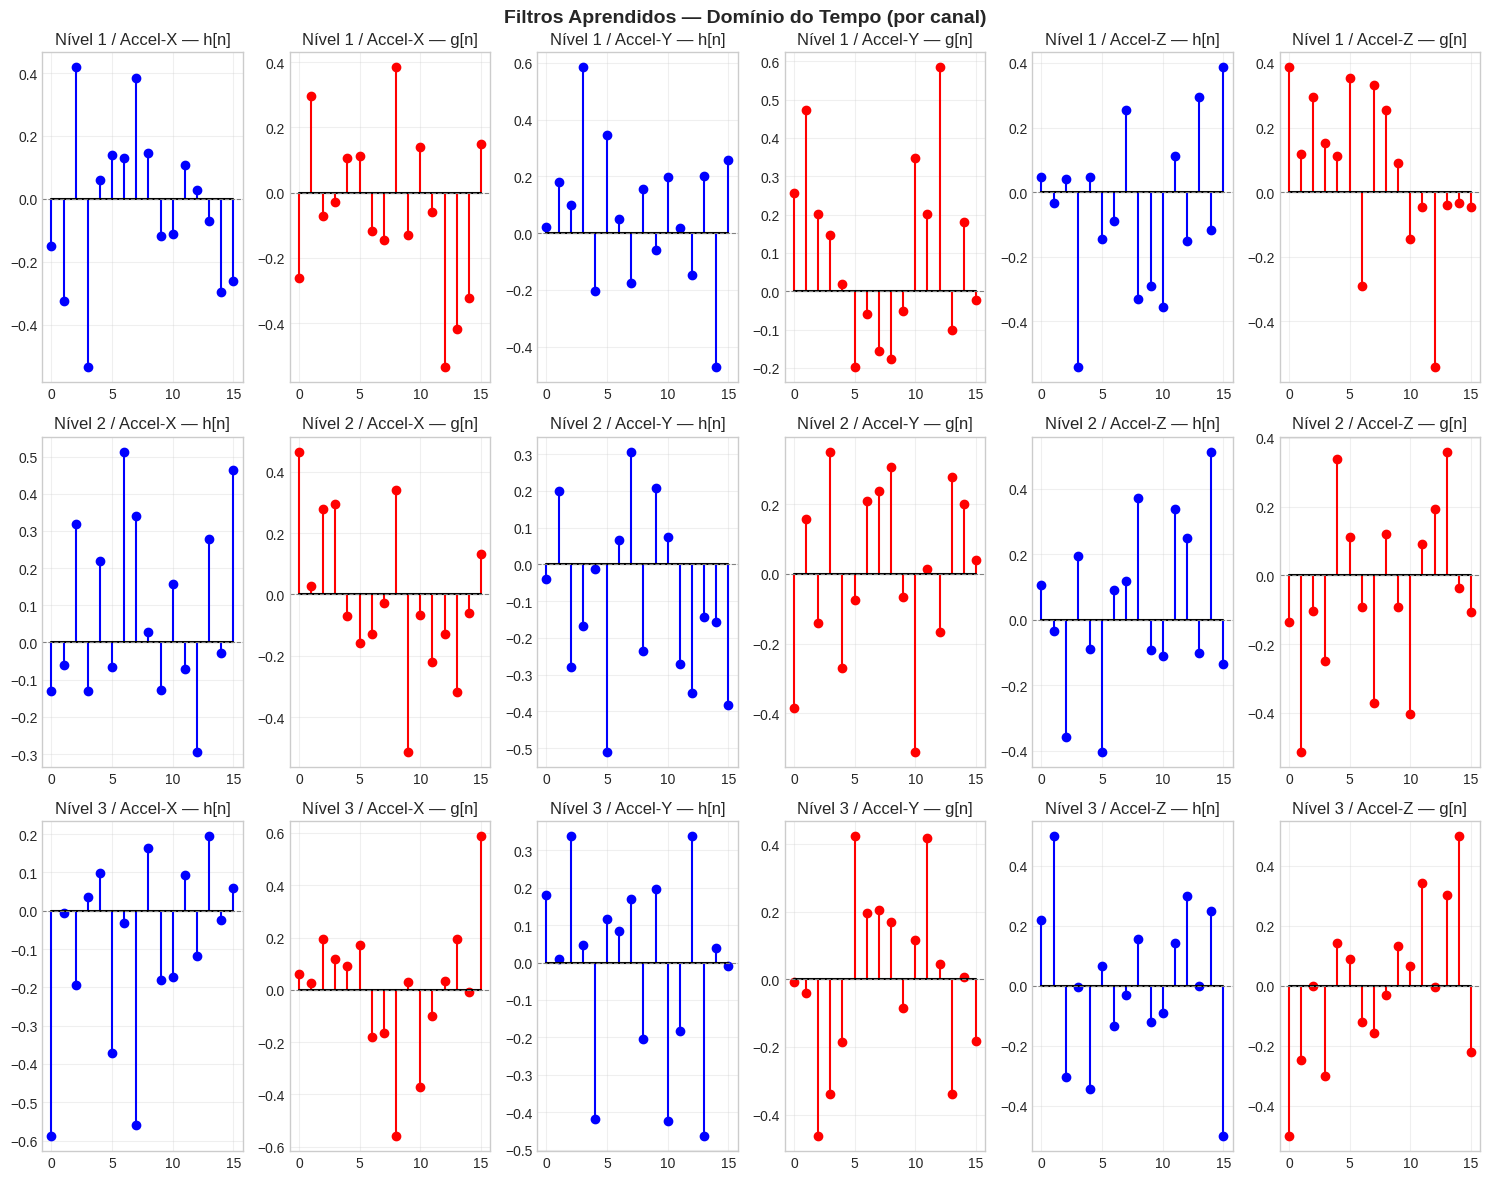

In [4]:
fig, axes = plt.subplots(n_levels, N_CHANNELS * 2, figsize=(5 * N_CHANNELS, 4 * n_levels))
if n_levels == 1:
    axes = axes.reshape(1, -1)

for i, filt in enumerate(filters):
    for ch in range(N_CHANNELS):
        h = filt['h'][ch]
        g = filt['g'][ch]

        ax_h = axes[i, ch * 2]
        ax_h.stem(h, linefmt='b-', markerfmt='bo', basefmt='k-')
        ax_h.set_title(f'Nível {filt["level"]} / {CHANNEL_NAMES[ch]} — h[n]')
        ax_h.axhline(0, color='gray', ls='--', lw=0.8)
        ax_h.grid(True, alpha=0.3)

        ax_g = axes[i, ch * 2 + 1]
        ax_g.stem(g, linefmt='r-', markerfmt='ro', basefmt='k-')
        ax_g.set_title(f'Nível {filt["level"]} / {CHANNEL_NAMES[ch]} — g[n]')
        ax_g.axhline(0, color='gray', ls='--', lw=0.8)
        ax_g.grid(True, alpha=0.3)

plt.suptitle('Filtros Aprendidos — Domínio do Tempo (por canal)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(FILTER_DIR / 'filters_time_domain.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. Propriedade 1 – Admissibilidade (Média Zero do High-Pass)

Uma função mãe wavelet $\psi$ deve satisfazer: $\sum_n g[n] = 0$

In [5]:
print('='*70)
print('PROPRIEDADE 1: Admissibilidade (média zero do high-pass)')
print('='*70)
print(f'{"Nível":>6} {"Canal":>10} | {"sum(g)":>12} | {"mean(g)":>12} | {"Status":>12}')
print('-' * 65)

admissibility_results = []
for filt in filters:
    for ch in range(N_CHANNELS):
        g = filt['g'][ch]
        g_sum = np.sum(g)
        g_mean = np.mean(g)
        passed = np.abs(g_sum) < 1e-4
        status = '✅ OK' if passed else f'⚠️  Dev={g_sum:.6f}'
        print(f"{filt['level']:>6} {CHANNEL_NAMES[ch]:>10} | {g_sum:>12.8f} | {g_mean:>12.8f} | {status:>12}")
        admissibility_results.append({
            'level': filt['level'], 'channel': CHANNEL_NAMES[ch],
            'sum_g': g_sum, 'passed': passed
        })

PROPRIEDADE 1: Admissibilidade (média zero do high-pass)
 Nível      Canal |       sum(g) |      mean(g) |       Status
-----------------------------------------------------------------
     1    Accel-X |  -0.90161186 |  -0.05635074 | ⚠️  Dev=-0.901612
     1    Accel-Y |   1.65124798 |   0.10320300 | ⚠️  Dev=1.651248
     1    Accel-Z |   0.94679976 |   0.05917498 | ⚠️  Dev=0.946800
     2    Accel-X |  -0.15454978 |  -0.00965936 | ⚠️  Dev=-0.154550
     2    Accel-Y |   0.17849439 |   0.01115590 | ⚠️  Dev=0.178494
     2    Accel-Z |  -0.88956898 |  -0.05559806 | ⚠️  Dev=-0.889569
     3    Accel-X |   0.13018048 |   0.00813628 | ⚠️  Dev=0.130180
     3    Accel-Y |  -0.04943471 |  -0.00308967 | ⚠️  Dev=-0.049435
     3    Accel-Z |   0.00098389 |   0.00006149 | ⚠️  Dev=0.000984


## 5. Propriedade 2 – Normalização (Norma L2 e Soma)

Para filtros ortogonais válidos:
- $\|h\|_2 = 1$ (energia unitária)
- $\sum_n h[n] = \sqrt{2}$ (condição de normalização para scaling function)

In [6]:
print('='*70)
print('PROPRIEDADE 2: Normalização dos Filtros')
print('='*70)
print(f'{"Nível":>6} {"Canal":>10} | {"||h||_2":>10} | {"||g||_2":>10} | {"sum(h)":>10} | {"sum(h)/√2":>10}')
print('-' * 75)

norm_results = []
for filt in filters:
    for ch in range(N_CHANNELS):
        h = filt['h'][ch]
        g = filt['g'][ch]
        h_l2 = np.linalg.norm(h)
        g_l2 = np.linalg.norm(g)
        h_sum = np.sum(h)
        h_ratio = h_sum / np.sqrt(2)
        print(f"{filt['level']:>6} {CHANNEL_NAMES[ch]:>10} | {h_l2:>10.6f} | {g_l2:>10.6f} | {h_sum:>10.6f} | {h_ratio:>10.6f}")
        norm_results.append({
            'level': filt['level'], 'channel': CHANNEL_NAMES[ch],
            'h_l2': h_l2, 'g_l2': g_l2, 'h_sum': h_sum
        })

print(f'\nNota: normalização usada = "{filters[0]["normalize_low"]}"')

PROPRIEDADE 2: Normalização dos Filtros
 Nível      Canal |    ||h||_2 |    ||g||_2 |     sum(h) |  sum(h)/√2
---------------------------------------------------------------------------
     1    Accel-X |   1.000000 |   1.000000 |  -0.459572 |  -0.324967
     1    Accel-Y |   1.000000 |   1.000000 |   1.058058 |   0.748160
     1    Accel-Z |   1.000000 |   1.000000 |  -0.882618 |  -0.624105
     2    Accel-X |   1.000000 |   1.000000 |   1.412369 |   0.998695
     2    Accel-Y |   1.000000 |   1.000000 |  -1.693875 |  -1.197750
     2    Accel-Z |   1.000000 |   1.000000 |   0.651345 |   0.460570
     3    Accel-X |   1.000000 |   1.000000 |  -1.605500 |  -1.135260
     3    Accel-Y |   1.000000 |   1.000000 |  -0.183444 |  -0.129714
     3    Accel-Z |   1.000000 |   1.000000 |   0.106605 |   0.075381

Nota: normalização usada = "l2"


## 6. Propriedade 3 – Relação QMF

O filtro high-pass é derivado do low-pass pela relação QMF:
$$g[n] = (-1)^n \cdot h[L{-}1{-}n]$$

In [7]:
print('='*70)
print('PROPRIEDADE 3: Relação QMF  g[n] = (-1)^n * h[L-1-n]')
print('='*70)

for filt in filters:
    for ch in range(N_CHANNELS):
        h = filt['h'][ch]
        g = filt['g'][ch]
        K = len(h)
        sign = np.array([(-1)**n for n in range(K)])
        g_expected = h[::-1] * sign
        error = np.max(np.abs(g - g_expected))
        passed = error < 1e-6
        status = '✅ OK' if passed else f'❌ Erro máx = {error:.2e}'
        print(f'  Nível {filt["level"]} / {CHANNEL_NAMES[ch]}: erro máximo = {error:.2e}  {status}')

PROPRIEDADE 3: Relação QMF  g[n] = (-1)^n * h[L-1-n]
  Nível 1 / Accel-X: erro máximo = 0.00e+00  ✅ OK
  Nível 1 / Accel-Y: erro máximo = 0.00e+00  ✅ OK
  Nível 1 / Accel-Z: erro máximo = 0.00e+00  ✅ OK
  Nível 2 / Accel-X: erro máximo = 0.00e+00  ✅ OK
  Nível 2 / Accel-Y: erro máximo = 0.00e+00  ✅ OK
  Nível 2 / Accel-Z: erro máximo = 0.00e+00  ✅ OK
  Nível 3 / Accel-X: erro máximo = 0.00e+00  ✅ OK
  Nível 3 / Accel-Y: erro máximo = 0.00e+00  ✅ OK
  Nível 3 / Accel-Z: erro máximo = 0.00e+00  ✅ OK


## 7. Propriedade 4 – Perfect Reconstruction (Condição de Nyquist)

$$|H(e^{j\omega})|^2 + |H(e^{j(\omega+\pi)})|^2 = 2 \quad \forall \omega$$

PROPRIEDADE 4: Perfect Reconstruction (Nyquist / Power Complementarity)


  Nível 1 / Accel-X: média=1.9990, desvio=99.23%  ⚠️  99.23%
  Nível 1 / Accel-Y: média=2.0018, desvio=169.11%  ⚠️  169.11%


  Nível 1 / Accel-Z: média=1.9997, desvio=149.87%  ⚠️  149.87%
  Nível 2 / Accel-X: média=2.0000, desvio=94.52%  ⚠️  94.52%
  Nível 2 / Accel-Y: média=2.0009, desvio=86.98%  ⚠️  86.98%
  Nível 2 / Accel-Z: média=1.9992, desvio=79.42%  ⚠️  79.42%


  Nível 3 / Accel-X: média=2.0006, desvio=131.02%  ⚠️  131.02%
  Nível 3 / Accel-Y: média=1.9981, desvio=101.09%  ⚠️  101.09%
  Nível 3 / Accel-Z: média=1.9981, desvio=99.43%  ⚠️  99.43%


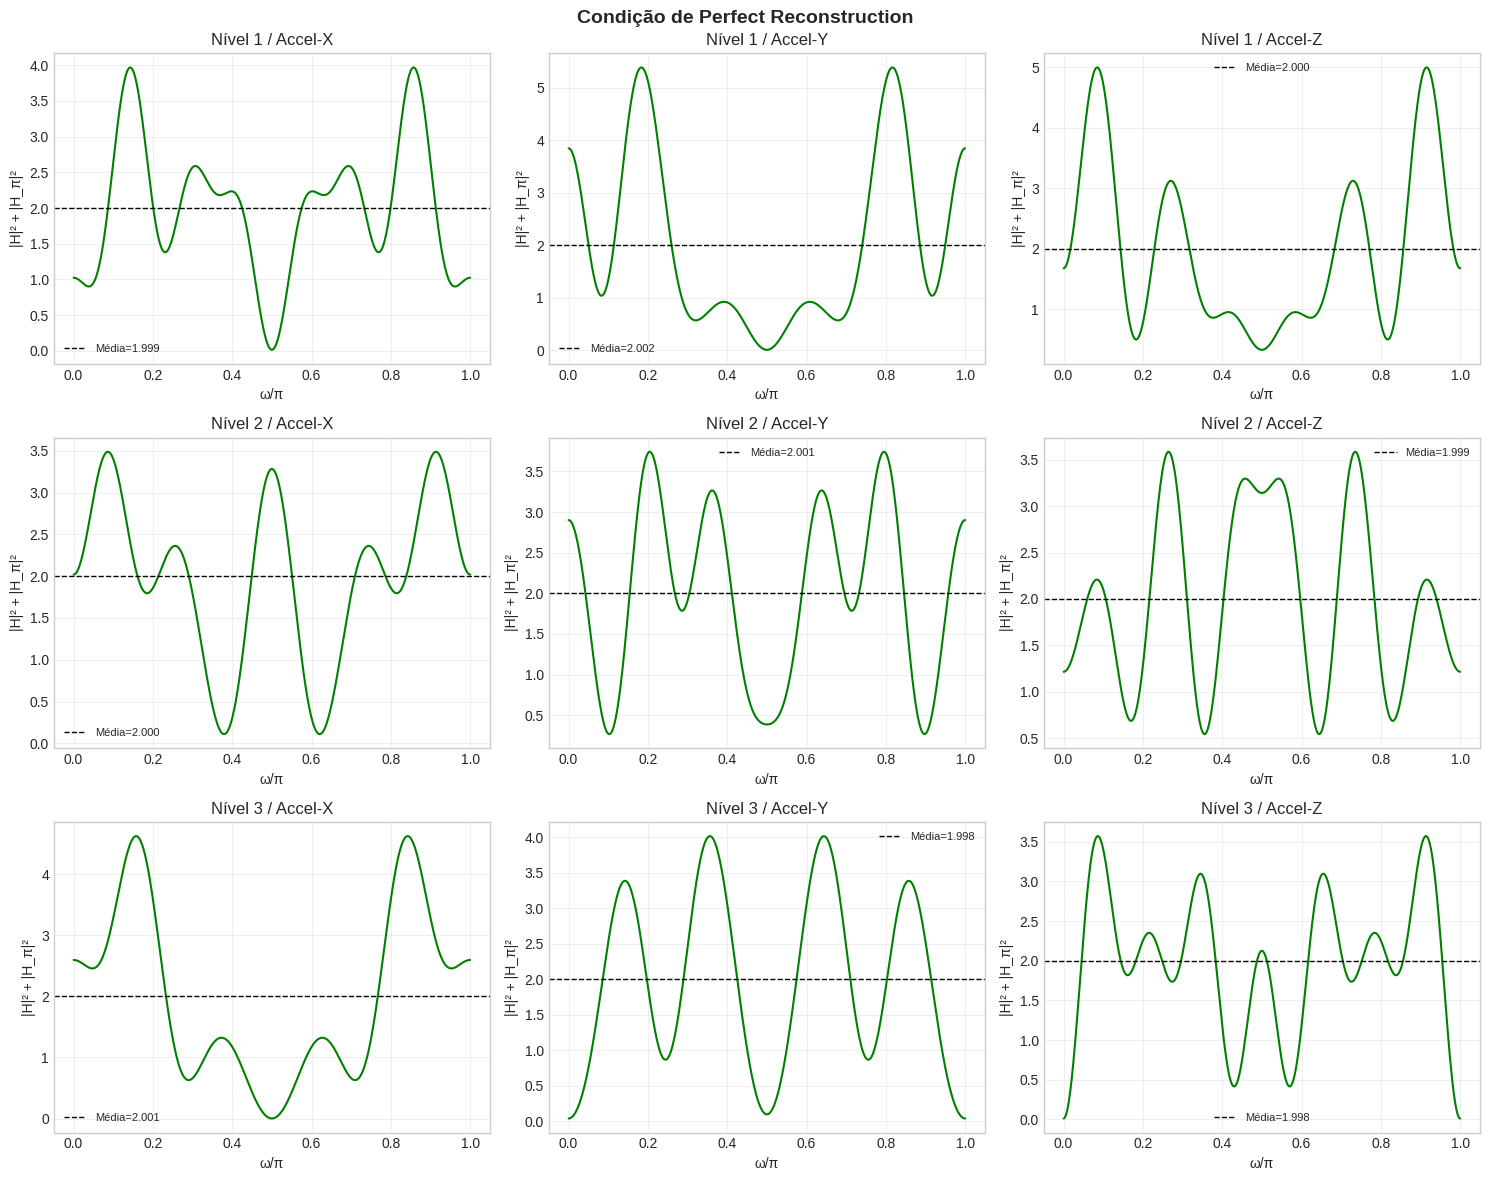

In [8]:
print('='*70)
print('PROPRIEDADE 4: Perfect Reconstruction (Nyquist / Power Complementarity)')
print('='*70)

N_freq = 1024
omega = np.linspace(0, np.pi, N_freq)

fig, axes = plt.subplots(n_levels, N_CHANNELS, figsize=(5 * N_CHANNELS, 4 * n_levels))
if n_levels == 1:
    axes = axes.reshape(1, -1)

pr_results = []
for i, filt in enumerate(filters):
    for ch in range(N_CHANNELS):
        h = filt['h'][ch]
        K = len(h)

        H = np.zeros(N_freq, dtype=complex)
        H_shifted = np.zeros(N_freq, dtype=complex)
        for n in range(K):
            H += h[n] * np.exp(-1j * omega * n)
            H_shifted += h[n] * np.exp(-1j * (omega + np.pi) * n)

        pr_sum = np.abs(H)**2 + np.abs(H_shifted)**2
        pr_mean = np.mean(pr_sum)
        pr_deviation = np.max(np.abs(pr_sum - pr_mean)) / pr_mean * 100

        passed = pr_deviation < 5.0
        status = '✅ OK' if passed else f'⚠️  {pr_deviation:.2f}%'
        print(f'  Nível {filt["level"]} / {CHANNEL_NAMES[ch]}: média={pr_mean:.4f}, desvio={pr_deviation:.2f}%  {status}')
        pr_results.append({
            'level': filt['level'], 'channel': CHANNEL_NAMES[ch],
            'pr_mean': pr_mean, 'pr_max_deviation_pct': pr_deviation, 'passed': passed
        })

        ax = axes[i, ch]
        ax.plot(omega / np.pi, pr_sum, 'g-', lw=1.5)
        ax.axhline(pr_mean, color='k', ls='--', lw=1, label=f'Média={pr_mean:.3f}')
        ax.set_title(f'Nível {filt["level"]} / {CHANNEL_NAMES[ch]}')
        ax.set_xlabel('ω/π')
        ax.set_ylabel('|H|² + |H_π|²')
        ax.legend(fontsize=8)
        ax.grid(True, alpha=0.3)

plt.suptitle('Condição de Perfect Reconstruction', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(FILTER_DIR / 'perfect_reconstruction.png', dpi=150, bbox_inches='tight')
plt.show()

## 8. Resposta em Frequência (Low-Pass / High-Pass)

RESPOSTA EM FREQUÊNCIA
  Nível 1 / Accel-X: h low-freq=44.1% ⚠️ | g high-freq=44.1% ⚠️
  Nível 1 / Accel-Y: h low-freq=24.8% ⚠️ | g high-freq=24.8% ⚠️
  Nível 1 / Accel-Z: h low-freq=44.2% ⚠️ | g high-freq=44.2% ⚠️
  Nível 2 / Accel-X: h low-freq=49.0% ⚠️ | g high-freq=49.2% ⚠️
  Nível 2 / Accel-Y: h low-freq=43.9% ⚠️ | g high-freq=43.9% ⚠️
  Nível 2 / Accel-Z: h low-freq=33.5% ⚠️ | g high-freq=33.7% ⚠️
  Nível 3 / Accel-X: h low-freq=42.7% ⚠️ | g high-freq=42.7% ⚠️
  Nível 3 / Accel-Y: h low-freq=25.7% ⚠️ | g high-freq=25.8% ⚠️
  Nível 3 / Accel-Z: h low-freq=44.1% ⚠️ | g high-freq=44.2% ⚠️


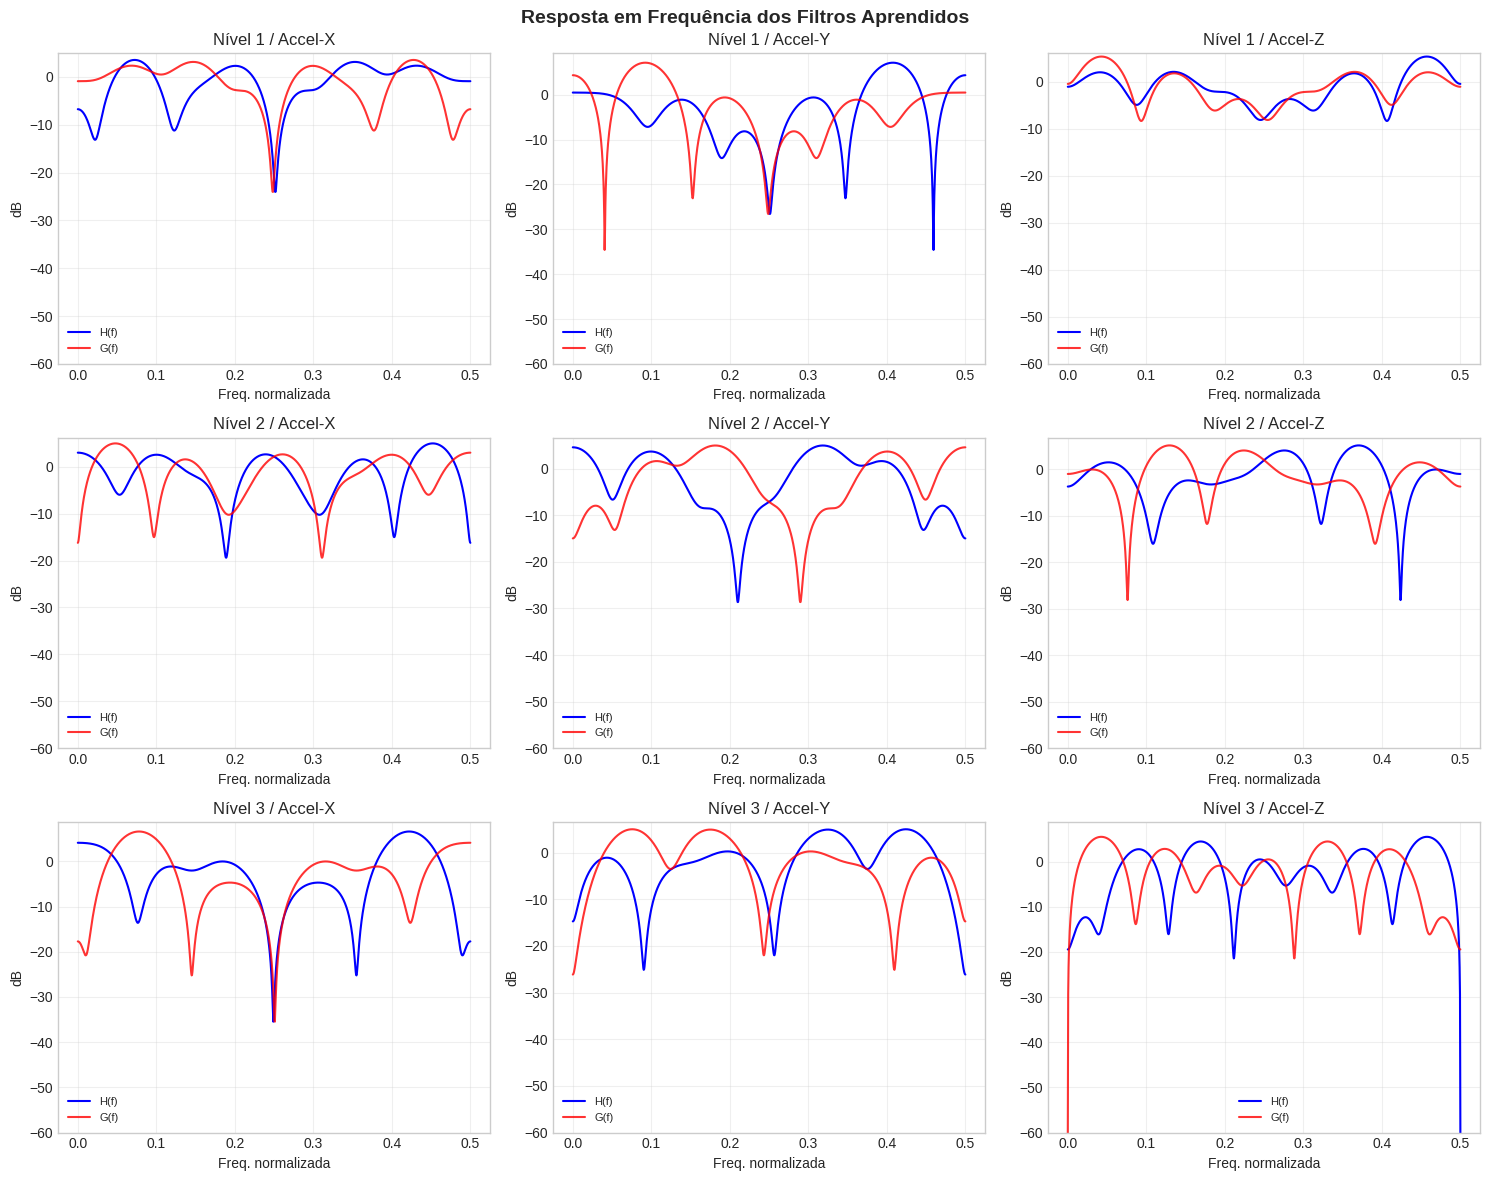

In [9]:
N_fft = 2048

fig, axes = plt.subplots(n_levels, N_CHANNELS, figsize=(5 * N_CHANNELS, 4 * n_levels))
if n_levels == 1:
    axes = axes.reshape(1, -1)

print('='*70)
print('RESPOSTA EM FREQUÊNCIA')
print('='*70)

for i, filt in enumerate(filters):
    for ch in range(N_CHANNELS):
        h = filt['h'][ch]
        g = filt['g'][ch]

        H = np.abs(np.fft.rfft(h, n=N_fft))
        G = np.abs(np.fft.rfft(g, n=N_fft))
        freqs = np.fft.rfftfreq(N_fft)

        half = len(freqs) // 2
        h_ratio = np.sum(H[:half]**2) / (np.sum(H**2) + 1e-12)
        g_ratio = np.sum(G[half:]**2) / (np.sum(G**2) + 1e-12)

        h_ok = '✅' if h_ratio > 0.6 else '⚠️'
        g_ok = '✅' if g_ratio > 0.6 else '⚠️'
        print(f'  Nível {filt["level"]} / {CHANNEL_NAMES[ch]}: h low-freq={h_ratio*100:.1f}% {h_ok} | g high-freq={g_ratio*100:.1f}% {g_ok}')

        ax = axes[i, ch]
        H_db = 20 * np.log10(H + 1e-12)
        G_db = 20 * np.log10(G + 1e-12)
        ax.plot(freqs, H_db, 'b-', label='H(f)', lw=1.5)
        ax.plot(freqs, G_db, 'r-', label='G(f)', lw=1.5, alpha=0.8)
        ax.set_title(f'Nível {filt["level"]} / {CHANNEL_NAMES[ch]}')
        ax.set_xlabel('Freq. normalizada')
        ax.set_ylabel('dB')
        ax.legend(fontsize=8)
        ax.grid(True, alpha=0.3)
        ax.set_ylim(bottom=-60)

plt.suptitle('Resposta em Frequência dos Filtros Aprendidos', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(FILTER_DIR / 'frequency_response.png', dpi=150, bbox_inches='tight')
plt.show()

## 9. Vanishing Moments do High-Pass

$$\sum_n n^k \cdot g[n] = 0, \quad k = 0, 1, \ldots, N{-}1$$

In [10]:
print('='*70)
print('VANISHING MOMENTS DO HIGH-PASS g')
print('='*70)

vm_results = []
for filt in filters:
    for ch in range(N_CHANNELS):
        g = filt['g'][ch]
        K = len(g)
        n_arr = np.arange(K, dtype=float)

        n_vanishing = 0
        for k in range(min(10, K)):
            moment = np.sum((n_arr ** k) * g)
            is_zero = np.abs(moment) < 1e-3
            if is_zero and k == n_vanishing:
                n_vanishing = k + 1

        vm_results.append({
            'level': filt['level'], 'channel': CHANNEL_NAMES[ch],
            'vanishing_moments': n_vanishing
        })
        print(f'  Nível {filt["level"]} / {CHANNEL_NAMES[ch]}: vanishing moments = {n_vanishing}')

print('\n  Referência (wavelets clássicas):')
for wname in ['db1', 'db2', 'db4', 'coif1', 'sym4']:
    w = pywt.Wavelet(wname)
    print(f'    {wname:>6}: vanishing moments = {w.dec_len // 2}')

VANISHING MOMENTS DO HIGH-PASS g
  Nível 1 / Accel-X: vanishing moments = 0
  Nível 1 / Accel-Y: vanishing moments = 0
  Nível 1 / Accel-Z: vanishing moments = 0
  Nível 2 / Accel-X: vanishing moments = 0
  Nível 2 / Accel-Y: vanishing moments = 0
  Nível 2 / Accel-Z: vanishing moments = 0
  Nível 3 / Accel-X: vanishing moments = 0
  Nível 3 / Accel-Y: vanishing moments = 0
  Nível 3 / Accel-Z: vanishing moments = 1

  Referência (wavelets clássicas):
       db1: vanishing moments = 1
       db2: vanishing moments = 2
       db4: vanishing moments = 4
     coif1: vanishing moments = 3
      sym4: vanishing moments = 4


## 10. Comparação com Wavelets Clássicas

In [11]:
classic_wavelets = {
    'db2': pywt.Wavelet('db2'),
    'db4': pywt.Wavelet('db4'),
    'sym4': pywt.Wavelet('sym4'),
    'coif1': pywt.Wavelet('coif1'),
}

def resample_filter(f, target_len):
    x_old = np.linspace(0, 1, len(f))
    x_new = np.linspace(0, 1, target_len)
    return np.interp(x_new, x_old, f)

print('='*70)
print('COMPARAÇÃO: Filtros Aprendidos vs Wavelets Clássicas (correlação Pearson)')
print('='*70)

corr_all = []
for filt in filters:
    for ch in range(N_CHANNELS):
        h_learned = filt['h'][ch]
        row = {'Nível': filt['level'], 'Canal': CHANNEL_NAMES[ch]}
        for wname, w in classic_wavelets.items():
            h_classic = resample_filter(np.array(w.dec_lo), len(h_learned))
            h_l = (h_learned - np.mean(h_learned)) / (np.std(h_learned) + 1e-12)
            h_c = (h_classic - np.mean(h_classic)) / (np.std(h_classic) + 1e-12)
            row[wname] = np.corrcoef(h_l, h_c)[0, 1]
        corr_all.append(row)

corr_df = pd.DataFrame(corr_all)
print(corr_df.to_string(index=False))

for _, row in corr_df.iterrows():
    wnames_only = {k: abs(v) for k, v in row.items() if k not in ('Nível', 'Canal')}
    best = max(wnames_only, key=wnames_only.get)
    print(f'  Nível {int(row["Nível"])} / {row["Canal"]}: mais similar a {best} (|r| = {wnames_only[best]:.4f})')

COMPARAÇÃO: Filtros Aprendidos vs Wavelets Clássicas (correlação Pearson)
 Nível   Canal       db2       db4      sym4     coif1
     1 Accel-X  0.100375 -0.199787  0.431809  0.355350
     1 Accel-Y -0.246296 -0.193618 -0.001850 -0.180684
     1 Accel-Z -0.044131  0.158042 -0.102182 -0.293117
     2 Accel-X -0.008878 -0.256295  0.377511 -0.089037
     2 Accel-Y -0.037286 -0.326422  0.205974  0.319682
     2 Accel-Z  0.311171  0.263468 -0.106240  0.177868
     3 Accel-X  0.291051  0.390346 -0.187536 -0.052258
     3 Accel-Y -0.317953 -0.297425  0.027771 -0.157867
     3 Accel-Z -0.047583  0.190438 -0.252936  0.048402
  Nível 1 / Accel-X: mais similar a sym4 (|r| = 0.4318)
  Nível 1 / Accel-Y: mais similar a db2 (|r| = 0.2463)
  Nível 1 / Accel-Z: mais similar a coif1 (|r| = 0.2931)
  Nível 2 / Accel-X: mais similar a sym4 (|r| = 0.3775)
  Nível 2 / Accel-Y: mais similar a db4 (|r| = 0.3264)
  Nível 2 / Accel-Z: mais similar a db2 (|r| = 0.3112)
  Nível 3 / Accel-X: mais similar a db4 (|

## 11. Localização Tempo-Frequência

$$\Delta t \cdot \Delta \omega \geq \frac{1}{2}$$

In [12]:
def time_freq_product(h):
    h = np.array(h, dtype=float)
    h2 = h**2
    h2_sum = np.sum(h2)
    if h2_sum < 1e-12:
        return np.inf, np.inf, np.inf
    h2_norm = h2 / h2_sum
    n = np.arange(len(h), dtype=float)
    t_mean = np.sum(n * h2_norm)
    t_var = np.sum((n - t_mean)**2 * h2_norm)
    delta_t = np.sqrt(t_var)

    N_fft = max(2048, len(h) * 16)
    H = np.abs(np.fft.rfft(h, n=N_fft))
    H2 = H**2
    H2_sum = np.sum(H2)
    if H2_sum < 1e-12:
        return delta_t, np.inf, np.inf
    H2_norm = H2 / H2_sum
    freqs = np.fft.rfftfreq(N_fft)
    f_mean = np.sum(freqs * H2_norm)
    f_var = np.sum((freqs - f_mean)**2 * H2_norm)
    delta_f = np.sqrt(f_var)
    return delta_t, delta_f, delta_t * delta_f

print('='*70)
print('LOCALIZAÇÃO TEMPO-FREQUÊNCIA')
print('='*70)
print(f'{"Filtro":>30} | {"Δt":>8} | {"Δω":>8} | {"Δt·Δω":>10}')
print('-' * 65)

for filt in filters:
    for ch in range(N_CHANNELS):
        dt, df, prod = time_freq_product(filt['h'][ch])
        label = f'Nível {filt["level"]} / {CHANNEL_NAMES[ch]}'
        print(f'{label:>30} | {dt:>8.4f} | {df:>8.4f} | {prod:>10.4f}')

print('-' * 65)
for wname, w in classic_wavelets.items():
    dt, df, prod = time_freq_product(np.array(w.dec_lo))
    print(f'{wname:>30} | {dt:>8.4f} | {df:>8.4f} | {prod:>10.4f}')
print('\nMenor produto = melhor localização (limite inferior: 0.5)')

LOCALIZAÇÃO TEMPO-FREQUÊNCIA
                        Filtro |       Δt |       Δω |      Δt·Δω
-----------------------------------------------------------------
             Nível 1 / Accel-X |   4.5736 |   0.1428 |     0.6530
             Nível 1 / Accel-Y |   5.0013 |   0.1516 |     0.7581
             Nível 1 / Accel-Z |   4.3415 |   0.1671 |     0.7256
             Nível 2 / Accel-X |   4.5897 |   0.1601 |     0.7347
             Nível 2 / Accel-Y |   4.3891 |   0.1405 |     0.6165
             Nível 2 / Accel-Z |   4.4884 |   0.1319 |     0.5918
             Nível 3 / Accel-X |   3.9286 |   0.1705 |     0.6699
             Nível 3 / Accel-Y |   4.1832 |   0.1169 |     0.4890
             Nível 3 / Accel-Z |   6.0299 |   0.1416 |     0.8537
-----------------------------------------------------------------
                           db2 |   0.5728 |   0.0904 |     0.0518
                           db4 |   0.7762 |   0.0822 |     0.0638
                          sym4 |   0.6522 |   0

## 12. Diversidade entre Canais e Níveis

Analisar se os filtros aprendidos diferem entre os 3 canais de acelerômetro
e entre os níveis — capacidade diferencial da LWT multicanal.

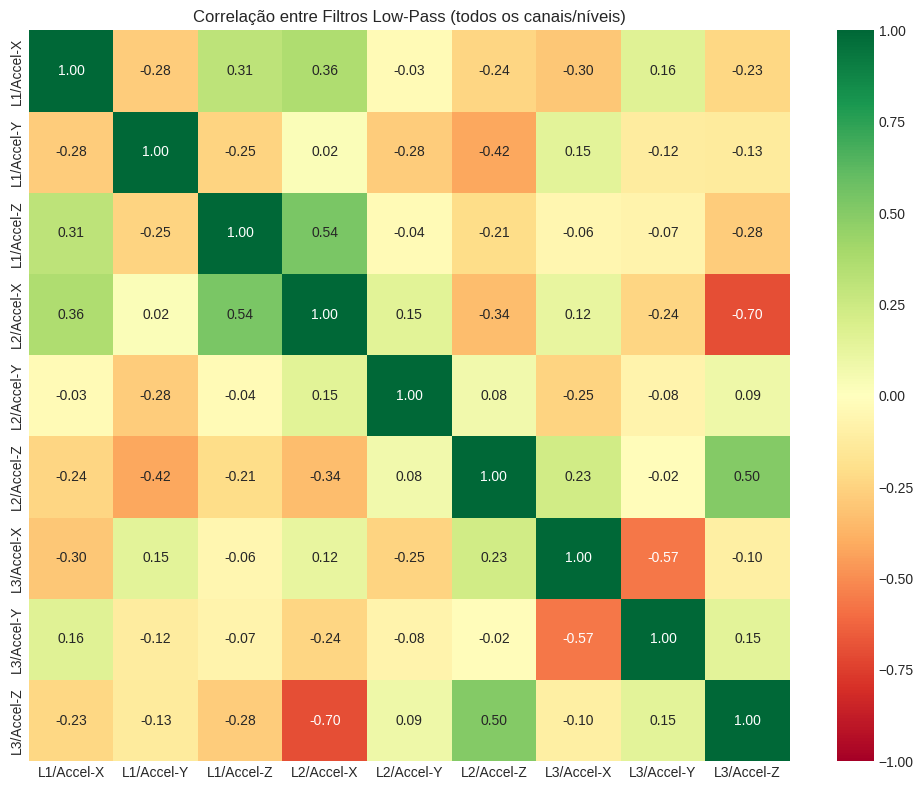


Diversidade entre CANAIS (mesmo nível):
  Nível 1: correlação média entre canais = -0.0716
  Nível 2: correlação média entre canais = -0.0360
  Nível 3: correlação média entre canais = -0.1732

Diversidade entre NÍVEIS (mesmo canal):
  Accel-X: correlação média entre níveis = 0.0614
  Accel-Y: correlação média entre níveis = -0.1597
  Accel-Z: correlação média entre níveis = 0.0056


In [13]:
import seaborn as sns

# Coletar todos os filtros h em lista flat: (n_levels * N_CHANNELS) filtros
all_h = []
labels = []
for filt in filters:
    for ch in range(N_CHANNELS):
        all_h.append(filt['h'][ch])
        labels.append(f'L{filt["level"]}/{CHANNEL_NAMES[ch]}')

n_total = len(all_h)
cross_corr = np.zeros((n_total, n_total))
for i in range(n_total):
    for j in range(n_total):
        cross_corr[i, j] = np.corrcoef(all_h[i], all_h[j])[0, 1]

fig, ax = plt.subplots(1, 1, figsize=(10, 8))
sns.heatmap(cross_corr, annot=True, fmt='.2f', cmap='RdYlGn',
            xticklabels=labels, yticklabels=labels, ax=ax,
            vmin=-1, vmax=1)
ax.set_title('Correlação entre Filtros Low-Pass (todos os canais/níveis)')
plt.tight_layout()
plt.savefig(FILTER_DIR / 'cross_channel_level_correlation.png', dpi=150, bbox_inches='tight')
plt.show()

# Análise: filtros iguais entre canais vs diferentes entre níveis?
print('\nDiversidade entre CANAIS (mesmo nível):')
for filt in filters:
    ch_corrs = []
    for c1 in range(N_CHANNELS):
        for c2 in range(c1+1, N_CHANNELS):
            r = np.corrcoef(filt['h'][c1], filt['h'][c2])[0, 1]
            ch_corrs.append(r)
    mean_r = np.mean(ch_corrs)
    print(f'  Nível {filt["level"]}: correlação média entre canais = {mean_r:.4f}')

print('\nDiversidade entre NÍVEIS (mesmo canal):')
for ch in range(N_CHANNELS):
    lv_corrs = []
    for i in range(n_levels):
        for j in range(i+1, n_levels):
            r = np.corrcoef(filters[i]['h'][ch], filters[j]['h'][ch])[0, 1]
            lv_corrs.append(r)
    mean_r = np.mean(lv_corrs)
    print(f'  {CHANNEL_NAMES[ch]}: correlação média entre níveis = {mean_r:.4f}')

## 13. Relatório Consolidado

In [14]:
print('\n' + '='*80)
print('📊 RELATÓRIO CONSOLIDADO — Análise dos Filtros Aprendidos (UWaveGesture)')
print('='*80)

summary_rows = []
vm_idx = 0
pr_idx = 0
for filt in filters:
    for ch in range(N_CHANNELS):
        h = filt['h'][ch]
        g = filt['g'][ch]
        K = len(h)

        # Admissibilidade
        g_sum = np.sum(g)

        # Norma
        h_l2 = np.linalg.norm(h)

        # QMF
        sign = np.array([(-1)**n for n in range(K)])
        g_expected = h[::-1] * sign
        qmf_err = np.max(np.abs(g - g_expected))

        # Vanishing moments
        vm = vm_results[vm_idx]['vanishing_moments']
        vm_idx += 1

        # PR deviation
        pr_dev = pr_results[pr_idx]['pr_max_deviation_pct']
        pr_idx += 1

        # Tempo-freq
        dt, df, prod = time_freq_product(h)

        row = {
            'Nível': filt['level'],
            'Canal': CHANNEL_NAMES[ch],
            'sum(g)': f'{g_sum:.6f}',
            '||h||_2': f'{h_l2:.4f}',
            'QMF err': f'{qmf_err:.2e}',
            'PR dev%': f'{pr_dev:.2f}',
            'V.M.': vm,
            'Δt·Δω': f'{prod:.4f}',
        }
        summary_rows.append(row)

summary_df = pd.DataFrame(summary_rows)
print(summary_df.to_string(index=False))

summary_df.to_csv(FILTER_DIR / 'filter_properties_summary.csv', index=False)
print(f'\n✅ Relatório salvo em: {FILTER_DIR / "filter_properties_summary.csv"}')

print('\n' + '-'*80)
print('INTERPRETAÇÃO:')
print('-'*80)
print('''
• Admissibilidade (sum(g)≈0): Garante que o high-pass tem média zero.
• Normalização: Com normalize_low="l2", ||h||_2=1 (energia unitária).
• QMF: Garantido por construção (erro deve ser ≈0).
• Perfect Reconstruction: Desvio <5% indica banco de filtros válido.
• Vanishing Moments: Quanto mais, melhor compressão de polinômios.
• Δt·Δω: Menor = melhor localização (limite inferior: 0.5).
• Diversidade entre canais: filtros diferentes indicam que a LWT
  aprendeu representações específicas para cada eixo do acelerômetro.
''')

print('\n🎉 Análise de filtros concluída!')


📊 RELATÓRIO CONSOLIDADO — Análise dos Filtros Aprendidos (UWaveGesture)
 Nível   Canal    sum(g) ||h||_2  QMF err PR dev%  V.M.  Δt·Δω
     1 Accel-X -0.901612  1.0000 0.00e+00   99.23     0 0.6530
     1 Accel-Y  1.651248  1.0000 0.00e+00  169.11     0 0.7581
     1 Accel-Z  0.946800  1.0000 0.00e+00  149.87     0 0.7256
     2 Accel-X -0.154550  1.0000 0.00e+00   94.52     0 0.7347
     2 Accel-Y  0.178494  1.0000 0.00e+00   86.98     0 0.6165
     2 Accel-Z -0.889569  1.0000 0.00e+00   79.42     0 0.5918
     3 Accel-X  0.130180  1.0000 0.00e+00  131.02     0 0.6699
     3 Accel-Y -0.049435  1.0000 0.00e+00  101.09     0 0.4890
     3 Accel-Z  0.000984  1.0000 0.00e+00   99.43     1 0.8537

✅ Relatório salvo em: /home/felipeteodoro/projetos/LearnableWaveletLayer/tests/uwave-gesture/results/filter_analysis/filter_properties_summary.csv

--------------------------------------------------------------------------------
INTERPRETAÇÃO:
----------------------------------------------------